# Ejercicio final - Clasificación con red multicapa

En este notebook usamos el dataset **Breast Cancer Wisconsin** de `sklearn` para resolver una tarea de clasificación binaria.

El entrenamiento incluye:
- monitorización del `val_loss` y guardado del mejor modelo,
- regularización con `Dropout` (y además `L2` con `weight_decay`),
- evaluación final en conjunto de test.

# Librerías

In [1]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Reproducibilidad

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cuda


# Carga de datos y particiones train/val/test

In [3]:
data = load_breast_cancer()
X = data.data
y = data.target

# 1) separamos test (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

# 2) del resto sacamos validación (20% de trainval -> 16% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=seed, stratify=y_trainval
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (364, 30), Val: (91, 30), Test: (114, 30)


# Preprocesado y DataLoader

In [4]:
# estandarizamos con estadísticas de train para evitar fuga de información
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Definición de la red

In [5]:
class CancerMLP(nn.Module):
    def __init__(self, in_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 2)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

model = CancerMLP(in_features=X_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
# L2 con weight_decay
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(model)

CancerMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)


# Entrenamiento con monitorización de validation loss

In [6]:
num_epochs = 120
best_val_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())

train_losses = []
val_losses = []

for epoch in range(1, num_epochs + 1):
    model.train()
    running_train_loss = 0.0
    n_train = 0

    for xB, yB in train_loader:
        xB, yB = xB.to(device), yB.to(device)

        optimizer.zero_grad()
        logits = model(xB)
        loss = criterion(logits, yB)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * xB.size(0)
        n_train += xB.size(0)

    epoch_train_loss = running_train_loss / n_train
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    n_val = 0
    with torch.no_grad():
        for xB, yB in val_loader:
            xB, yB = xB.to(device), yB.to(device)
            logits = model(xB)
            loss = criterion(logits, yB)
            running_val_loss += loss.item() * xB.size(0)
            n_val += xB.size(0)

    epoch_val_loss = running_val_loss / n_val
    val_losses.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_state = copy.deepcopy(model.state_dict())

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d}/{num_epochs} | "
            f"train_loss = {epoch_train_loss:.4f} | val_loss = {epoch_val_loss:.4f}"
        )

# restauramos el mejor modelo según validation loss
model.load_state_dict(best_state)
print(f"Mejor val_loss: {best_val_loss:.4f}")

Epoch 001/120 | train_loss = 0.6573 | val_loss = 0.5985
Epoch 010/120 | train_loss = 0.0657 | val_loss = 0.0925
Epoch 020/120 | train_loss = 0.0425 | val_loss = 0.0888
Epoch 030/120 | train_loss = 0.0321 | val_loss = 0.0924
Epoch 040/120 | train_loss = 0.0144 | val_loss = 0.0983
Epoch 050/120 | train_loss = 0.0074 | val_loss = 0.0972
Epoch 060/120 | train_loss = 0.0072 | val_loss = 0.1076
Epoch 070/120 | train_loss = 0.0099 | val_loss = 0.1143
Epoch 080/120 | train_loss = 0.0026 | val_loss = 0.1111
Epoch 090/120 | train_loss = 0.0096 | val_loss = 0.1035
Epoch 100/120 | train_loss = 0.0042 | val_loss = 0.1048
Epoch 110/120 | train_loss = 0.0020 | val_loss = 0.1126
Epoch 120/120 | train_loss = 0.0011 | val_loss = 0.1208
Mejor val_loss: 0.0856


# Curvas de entrenamiento

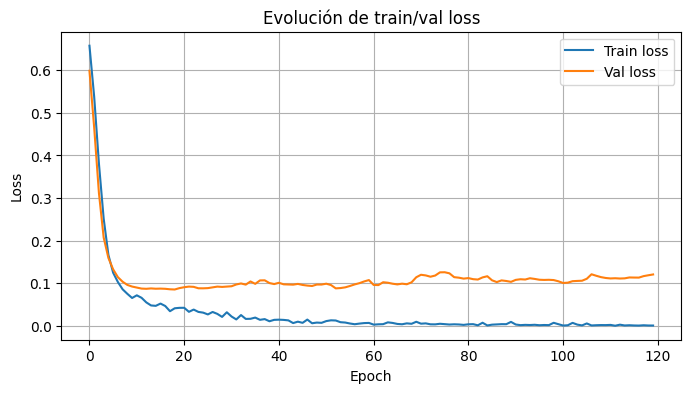

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de train/val loss")
plt.legend()
plt.grid(True)
plt.show()

# Evaluación en test

In [8]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for xB, yB in test_loader:
        xB = xB.to(device)
        logits = model(xB)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds.tolist())
        all_targets.extend(yB.numpy().tolist())

test_acc = accuracy_score(all_targets, all_preds)
print(f"Test accuracy: {test_acc:.4f}")

print("\nClassification report:")
print(classification_report(all_targets, all_preds, target_names=data.target_names))

print("Matriz de confusión:")
print(confusion_matrix(all_targets, all_preds))

Test accuracy: 0.9649

Classification report:
              precision    recall  f1-score   support

   malignant       0.95      0.95      0.95        42
      benign       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

Matriz de confusión:
[[40  2]
 [ 2 70]]


# Conclusión

Se ha entrenado una red neuronal multicapa con regularización (`Dropout` + `L2`) y selección del mejor modelo según `val_loss`.

Finalmente, el mejor modelo se ha evaluado en test, cumpliendo todos los requisitos del ejercicio final.